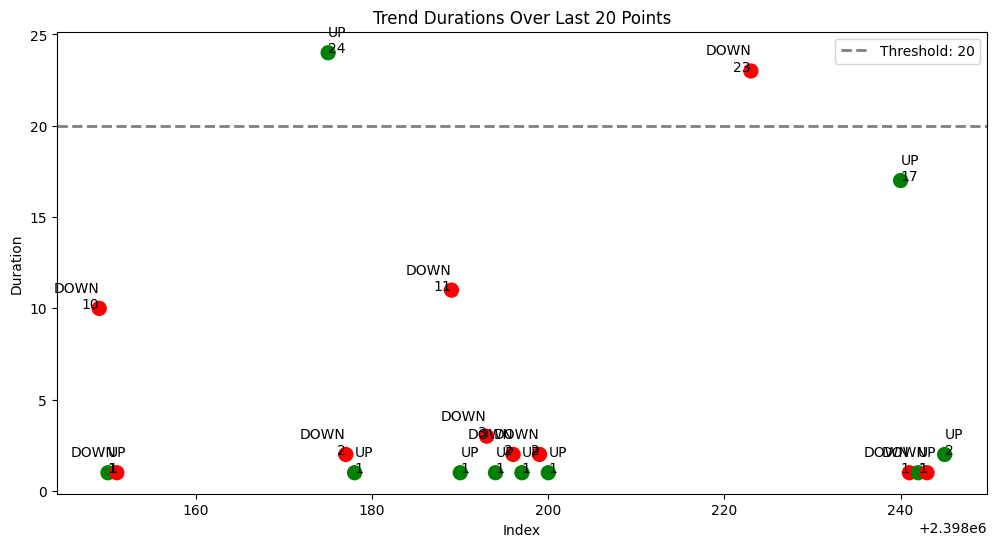

In [8]:
import feather
import pandas as pd
import talib
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
dataset_path = '/allah/freqtrade/user_data/data/binance/futures/ETH_USDT_USDT-1m-futures.feather'
dataframe = feather.read_dataframe(dataset_path)

# Calculate Triple Exponential Moving Average (TEMA) on closing prices
tema_period = 50
dataframe['tema'] = talib.TEMA(dataframe['close'], timeperiod=tema_period)

# Establish the trend direction
conditions = [
    dataframe['tema'] > dataframe['tema'].shift(1),
    dataframe['tema'] < dataframe['tema'].shift(1)
]
choices = ['DOWN', 'UP']
dataframe['trend'] = np.select(conditions, choices, default='STABLE')

# Identify trend change points
dataframe['trend_change'] = dataframe['trend'] != dataframe['trend'].shift(1)
dataframe['trend_change_point'] = dataframe['trend_change'] & (dataframe['trend'] != 'STABLE')

# Create a separate DataFrame for change points to avoid SettingWithCopyWarning
change_points = dataframe[dataframe['trend_change_point']].copy()
change_points['duration'] = change_points.index.to_series().diff().fillna(0)

# Format data for plotting
change_points = change_points.round({'tema': 2, 'volume': 2})
if 'date' in change_points.columns:
    change_points['date'] = change_points['date'].dt.strftime('%Y-%m-%d %H:%M')

# Prepare for visualization
plot_data = change_points.copy()
plot_data['previous_trend'] = plot_data['trend'].shift(1)
plot_data.dropna(subset=['duration'], inplace=True)

# Define parameters for the plot
plot_window = 20
plot_data = plot_data.tail(plot_window)

# Create the scatter plot
plt.figure(figsize=(12, 6))
trend_colors = {'UP': 'red', 'DOWN': 'green', 'STABLE': 'blue'}
plt.scatter(plot_data.index, plot_data['duration'], 
            c=plot_data['previous_trend'].map(trend_colors), 
            marker='o', s=100)

# Additional plot formatting
plt.axhline(y=20, color='gray', linestyle='--', linewidth=2, label='Threshold: 20')
plt.xlabel('Index')
plt.ylabel('Duration')
plt.title(f'Trend Durations Over Last {plot_window} Points')

# Annotate points
for idx, row in plot_data.iterrows():
    alignment = 'right' if row['trend'] == 'DOWN' else 'left'
    plt.text(idx, row['duration'], f"{row['trend']}\n{int(row['duration'])}", ha=alignment)

plt.legend()
plt.show()


In [18]:
import feather
import pandas as pd
import talib
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
dataset_path = '/allah/freqtrade/user_data/data/binance/futures/ETH_USDT_USDT-1m-futures.feather'
dataframe = feather.read_dataframe(dataset_path)

# Calculate Triple Exponential Moving Average (TEMA) on closing prices
tema_period = 50
dataframe['tema'] = talib.TEMA(dataframe['close'], timeperiod=tema_period)

# Establish the trend direction
conditions = [
    dataframe['tema'] > dataframe['tema'].shift(1),
    dataframe['tema'] < dataframe['tema'].shift(1)
]
choices = ['DOWN', 'UP']
dataframe['trend'] = np.select(conditions, choices, default='STABLE')

# Identify trend change points
dataframe['trend_change'] = dataframe['trend'] != dataframe['trend'].shift(1)
dataframe['trend_change_point'] = dataframe['trend_change'] & (dataframe['trend'] != 'STABLE')

# Create a separate DataFrame for change points to avoid SettingWithCopyWarning
change_points = dataframe[dataframe['trend_change_point']].copy()
change_points['duration'] = change_points.index.to_series().diff().fillna(0)

# Format data for plotting (this step is kept for possible later usage)
change_points = change_points.round({'tema': 2, 'volume': 2})
if 'date' in change_points.columns:
    change_points['date'] = change_points['date'].dt.strftime('%Y-%m-%d %H:%M')

# Calculate signed durations based on trend
change_points['signed_duration'] = change_points.apply(lambda row: row['duration'] if row['trend'] == 'UP' else -row['duration'], axis=1)

# Extracting the signed durations list
duration_list = change_points['signed_duration'].tolist()

# Optionally, print or use this list
print(duration_list)


[-0.0, 61.0, -1.0, 2.0, -2.0, 1.0, -4.0, 6.0, -1.0, 2.0, -2.0, 2.0, -1.0, 13.0, -4.0, 3.0, -1.0, 1.0, -2.0, 14.0, -1.0, 1.0, -5.0, 2.0, -1.0, 4.0, -12.0, 1.0, -3.0, 5.0, -15.0, 1.0, -1.0, 7.0, -1.0, 5.0, -1.0, 1.0, -1.0, 11.0, -13.0, 17.0, -1.0, 4.0, -24.0, 3.0, -6.0, 1.0, -1.0, 1.0, -3.0, 2.0, -3.0, 13.0, -1.0, 2.0, -1.0, 51.0, -20.0, 1.0, -1.0, 1.0, -1.0, 13.0, -4.0, 27.0, -4.0, 9.0, -3.0, 1.0, -4.0, 2.0, -3.0, 1.0, -4.0, 5.0, -2.0, 2.0, -4.0, 1.0, -1.0, 1.0, -3.0, 10.0, -6.0, 4.0, -35.0, 1.0, -7.0, 36.0, -15.0, 1.0, -5.0, 8.0, -3.0, 1.0, -1.0, 24.0, -35.0, 6.0, -10.0, 3.0, -18.0, 23.0, -1.0, 27.0, -26.0, 3.0, -13.0, 21.0, -35.0, 54.0, -7.0, 6.0, -23.0, 1.0, -1.0, 3.0, -2.0, 1.0, -10.0, 2.0, -2.0, 1.0, -1.0, 2.0, -4.0, 1.0, -1.0, 1.0, -5.0, 1.0, -1.0, 1.0, -1.0, 3.0, -1.0, 1.0, -9.0, 1.0, -1.0, 2.0, -7.0, 1.0, -6.0, 2.0, -2.0, 32.0, -1.0, 5.0, -27.0, 1.0, -1.0, 24.0, -29.0, 7.0, -29.0, 1.0, -7.0, 19.0, -1.0, 1.0, -4.0, 38.0, -1.0, 1.0, -15.0, 2.0, -4.0, 6.0, -1.0, 4.0, -5.0, 10.0, -2

In [19]:
duration_list
# tail of list
duration_list[-10:]
# len of list
len(duration_list)

315875

In [9]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import TensorBoard
import os
import datetime

# Example duration data (replace this with 'duration_list' from your previous script)
# Make sure 'duration_list' is defined and loaded
duration_data = np.array(duration_list)

# Reshape and scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
duration_data = duration_data.reshape(-1, 1)  # Reshape to fit the scaler
scaled_data = scaler.fit_transform(duration_data)

# Prepare data for LSTM
def create_dataset(data, step_size):
    X, y = [], []
    for i in range(len(data) - step_size - 1):
        a = data[i:(i + step_size), 0]  # X values: 50 data points
        X.append(a)
        y.append(data[i + step_size, 0])  # y value: the next data point
    return np.array(X), np.array(y)

# Use step size of 50
step_size = 100
X, y = create_dataset(scaled_data, step_size)

# Split data into training and validation sets
split_ratio = 0.8  # 80% for training, 20% for validation
split = int(X.shape[0] * split_ratio)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# Setup TensorBoard
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Build LSTM model
model = Sequential()
model.add(LSTM(50, input_shape=(step_size, 1), return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model with validation data and TensorBoard logging
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1, validation_data=(X_val, y_val), callbacks=[tensorboard_callback])

# Predicting the next value
def predict_next_value(data):
    # Last 'step_size' values from data to predict the next value
    last_sequence = data[-step_size:]
    last_sequence = scaler.transform(last_sequence.reshape(-1, 1))  # Scale the data
    last_sequence = last_sequence.reshape((1, step_size, 1))  # Reshape for the model
    predicted_value = model.predict(last_sequence)
    predicted_value = scaler.inverse_transform(predicted_value)  # Inverse scaling
    return predicted_value[0, 0]

# Example use: predict the next value
next_value = predict_next_value(duration_data)
print("Predicted next value:", next_value)


2024-06-18 14:36:02.323666: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-18 14:36:03.118922: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Epoch 1/20


/allah/freqtrade/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7895/7895 ━━━━━━━━━━━━━━━━━━━━ 463s 58ms/step - loss: 0.0029 - val_loss: 0.0017
Epoch 2/20
7895/7895 ━━━━━━━━━━━━━━━━━━━━ 445s 56ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 3/20
7895/7895 ━━━━━━━━━━━━━━━━━━━━ 443s 56ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 4/20
7895/7895 ━━━━━━━━━━━━━━━━━━━━ 442s 56ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 5/20
7895/7895 ━━━━━━━━━━━━━━━━━━━━ 444s 56ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 6/20
7895/7895 ━━━━━━━━━━━━━━━━━━━━ 441s 56ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 7/20
7895/7895 ━━━━━━━━━━━━━━━━━━━━ 440s 56ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 8/20
5439/7895 ━━━━━━━━━━━━━━━━━━━━ 2:08 52ms/step - loss: 0.0016

KeyboardInterrupt: 

In [21]:
duration_data = np.array(duration_list)


In [25]:
duration_data[-10:]

array([  2.,  -1.,   1.,  -9.,  35.,  -1.,   5., -29.,  10.,  -1.])

In [28]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import TensorBoard
import os
import datetime

# Example duration data (replace this with 'duration_list' from your previous script)
# Make sure 'duration_list' is defined and loaded
duration_data = np.array(duration_list)

# Define a threshold value for classification
threshold = 20

# Reshape and scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
# Apply absolute to duration_data to consider both negative and positive high values
duration_data = duration_data.reshape(-1, 1)  # Reshape to fit the scaler
abs_duration_data = np.abs(duration_data)

scaled_data = scaler.fit_transform(abs_duration_data)

# Prepare data for LSTM
def create_dataset(data, step_size, scaled_threshold):
    X, y = [], []
    for i in range(len(data) - step_size - 1):
        a = data[i:(i + step_size), 0]  # X values: 100 data points
        X.append(a)
        # Check if the next value's absolute is above the threshold
        y.append(1 if data[i + step_size, 0] > scaled_threshold else 0)
    return np.array(X), np.array(y)

# Convert threshold to scaled value once using the fitted scaler
scaled_threshold = scaler.transform([[threshold]])[0, 0]

# Use step size of 100
step_size = 30
X, y = create_dataset(scaled_data, step_size, scaled_threshold)

# Split data into training and validation sets
split_ratio = 0.8  # 80% for training, 20% for validation
split = int(X.shape[0] * split_ratio)
X_train, X_val = X[:split], X[split:]
y_train, y_val = y[:split], y[split:]

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))

# Setup TensorBoard
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Build LSTM model for binary classification
model = Sequential()
model.add(LSTM(50, input_shape=(step_size, 1), return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1, activation='sigmoid'))  # Use sigmoid for binary classification

# Compile the model with binary cross-entropy loss
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with validation data and TensorBoard logging
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1, validation_data=(X_val, y_val), callbacks=[tensorboard_callback])

# Predicting if the next value exceeds the threshold
def predict_next_value(data):
    # Last 'step_size' values from data to predict the next value
    last_sequence = data[-step_size:]
    last_sequence = scaler.transform(np.abs(last_sequence.reshape(-1, 1)))  # Scale the data considering absolute value
    last_sequence = last_sequence.reshape((1, step_size, 1))  # Reshape for the model
    predicted_prob = model.predict(last_sequence)
    predicted_class = (predicted_prob > 0.5).astype(int)
    return predicted_class[0, 0]

# Example use: predict whether the next value exceeds the threshold
next_value_exceeds_threshold = predict_next_value(duration_data)
print("Does the predicted next value exceed the threshold? ", "Yes" if next_value_exceeds_threshold else "No")


Epoch 1/20


/allah/freqtrade/.venv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7897/7897 ━━━━━━━━━━━━━━━━━━━━ 130s 16ms/step - accuracy: 0.8977 - loss: 0.3322 - val_accuracy: 0.8949 - val_loss: 0.3336
Epoch 2/20
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 131s 17ms/step - accuracy: 0.8980 - loss: 0.3253 - val_accuracy: 0.8949 - val_loss: 0.3314
Epoch 3/20
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 129s 16ms/step - accuracy: 0.8976 - loss: 0.3262 - val_accuracy: 0.8949 - val_loss: 0.3312
Epoch 4/20
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 128s 16ms/step - accuracy: 0.8989 - loss: 0.3232 - val_accuracy: 0.8949 - val_loss: 0.3314
Epoch 5/20
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 129s 16ms/step - accuracy: 0.8983 - loss: 0.3243 - val_accuracy: 0.8949 - val_loss: 0.3311
Epoch 6/20
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 129s 16ms/step - accuracy: 0.8985 - loss: 0.3242 - val_accuracy: 0.8949 - val_loss: 0.3311
Epoch 7/20
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 130s 16ms/step - accuracy: 0.8982 - loss: 0.3246 - val_accuracy: 0.8949 - val_loss: 0.3313
Epoch 8/20
7897/7897 ━━━━━━━━━━━━━━━━━━━━ 129s 16ms/step - accuracy: 0.8978 - lo

In [30]:
import feather
import pandas as pd
import talib
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
dataset_path = '/allah/freqtrade/user_data/data/binance/futures/ETH_USDT_USDT-1m-futures.feather'
dataframe = feather.read_dataframe(dataset_path)

# Calculate Triple Exponential Moving Average (TEMA) on closing prices
tema_period = 50
dataframe['tema'] = talib.TEMA(dataframe['close'], timeperiod=tema_period)

# Establish the trend direction
conditions = [
    dataframe['tema'] > dataframe['tema'].shift(1),
    dataframe['tema'] < dataframe['tema'].shift(1)
]
choices = ['DOWN', 'UP']
dataframe['trend'] = np.select(conditions, choices, default='STABLE')

# Identify trend change points
dataframe['trend_change'] = dataframe['trend'] != dataframe['trend'].shift(1)
dataframe['trend_change_point'] = dataframe['trend_change'] & (dataframe['trend'] != 'STABLE')

# Create a separate DataFrame for change points to avoid SettingWithCopyWarning
change_points = dataframe[dataframe['trend_change_point']].copy()
change_points['duration'] = change_points.index.to_series().diff().fillna(0)

# Format data for plotting
change_points = change_points.round({'tema': 2, 'volume': 2})
if 'date' in change_points.columns:
    change_points['date'] = change_points['date'].dt.strftime('%Y-%m-%d %H:%M')

# Prepare for visualization
plot_data = change_points.copy()
plot_data['previous_trend'] = plot_data['trend'].shift(1)
plot_data.dropna(subset=['duration'], inplace=True)

# Define parameters for the plot
plot_window = 20
plot_data = plot_data.tail(plot_window)

# Create the scatter plot
plt.figure(figsize=(12, 6))
trend_colors = {'UP': 'red', 'DOWN': 'green', 'STABLE': 'blue'}
plt.scatter(plot_data.index, plot_data['duration'], 
            c=plot_data['previous_trend'].map(trend_colors), 
            marker='o', s=100)

# Additional plot formatting
plt.axhline(y=20, color='gray', linestyle='--', linewidth=2, label='Threshold: 20')
plt.xlabel('Index')
plt.ylabel('Duration')
plt.title(f'Trend Durations Over Last {plot_window} Points')

# Annotate points
for idx, row in plot_data.iterrows():
    alignment = 'right' if row['trend'] == 'DOWN' else 'left'
    plt.text(idx, row['duration'], f"{row['trend']}\n{int(row['duration'])}", ha=alignment)

plt.legend()
plt.show()


ArrowInvalid: Not an Arrow file